# 18 · 9-panel supplementary network grid

3 arms (All, DBS, Never-DBS) × 3 windows (Pre, Early post, Late post) partial-correlation heatmaps. Gives reviewers a direct view of the full network topology rather than just summary statistics.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(patchwork)
})
gf <- readRDS(file.path(OUT_OBJ, "longitudinal_glasso_full.rds"))
grid <- gf$grid
fits <- gf$fits
cat("Grid:\n"); print(grid)

Grid:


# A tibble: 9 × 3
  window     arm           n
  <chr>      <chr>     <int>
1 pre        All        1051
2 pre        DBS         124
3 pre        Never-DBS   927
4 early_post All         543
5 early_post DBS          68
6 early_post Never-DBS   475
7 late_post  All         464
8 late_post  DBS          58
9 late_post  Never-DBS   406


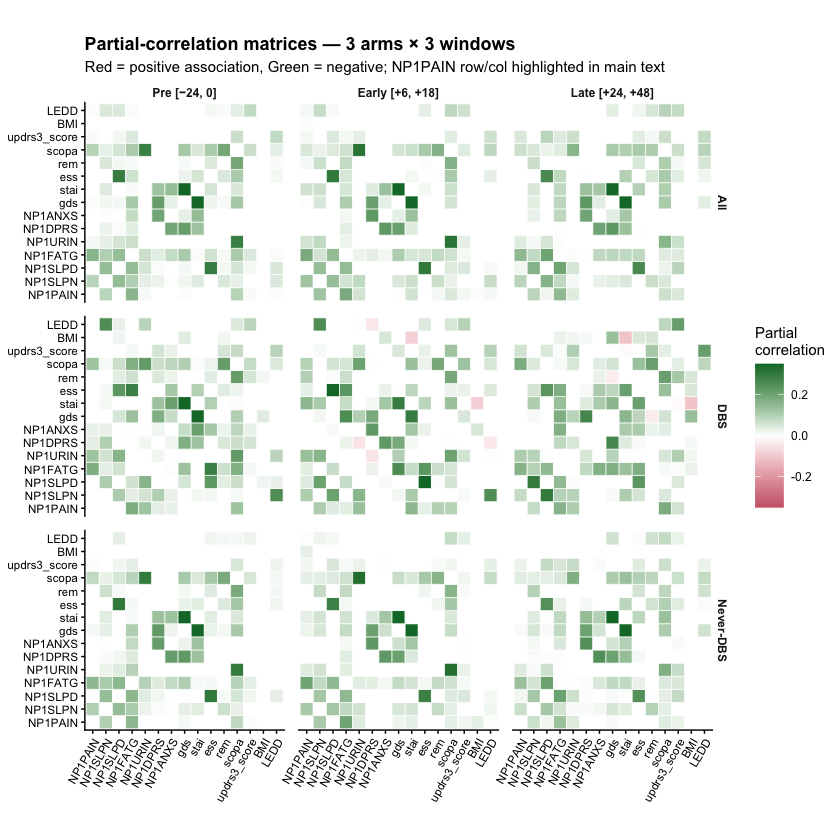

In [2]:
# Convert a partial correlation matrix to tidy long form for heatmap
to_long <- function(P, window, arm) {
  nn <- rownames(P)
  as.data.frame(P) %>% tibble::rownames_to_column("row") %>%
    tidyr::pivot_longer(-row, names_to = "col", values_to = "pcor") %>%
    dplyr::mutate(row = factor(row, levels = nn),
                  col = factor(col, levels = nn),
                  window = window, arm = arm)
}

panels <- purrr::map_dfr(seq_len(nrow(grid)), function(i) {
  f <- fits[[i]]; if (is.null(f)) return(NULL)
  to_long(f$P, grid$window[i], grid$arm[i])
})
panels$window <- factor(panels$window, levels = c("pre","early_post","late_post"),
                        labels = c("Pre [−24, 0]", "Early [+6, +18]", "Late [+24, +48]"))
panels$arm <- factor(panels$arm, levels = c("All", "DBS", "Never-DBS"))

# Highlight NP1PAIN row/col
pain_labels <- function(x) ifelse(as.character(x) == "NP1PAIN",
                                  paste0("**", as.character(x), "**"),
                                  as.character(x))
p_grid <- ggplot(panels, aes(col, row, fill = pcor)) +
  geom_tile(colour = "white", linewidth = 0.2) +
  scale_fill_gradient2(low = "#CC6677", mid = "white", high = "#117733",
                       midpoint = 0, limits = c(-0.35, 0.35), oob = scales::squish,
                       name = "Partial\ncorrelation") +
  facet_grid(arm ~ window) +
  coord_fixed() +
  labs(title = "Partial-correlation matrices — 3 arms × 3 windows",
       subtitle = "Red = positive association, Green = negative; NP1PAIN row/col highlighted in main text",
       x = NULL, y = NULL) +
  theme_classic(base_size = 9) +
  theme(plot.title = element_text(face = "bold"),
        axis.text.x = element_text(angle = 60, hjust = 1, size = 7),
        axis.text.y = element_text(size = 7),
        strip.background = element_blank(),
        strip.text = element_text(face = "bold"),
        panel.spacing = unit(0.6, "lines"))
p_grid
save_fig(p_grid, "FigureS1_network_panel_grid", width = 13, height = 12)

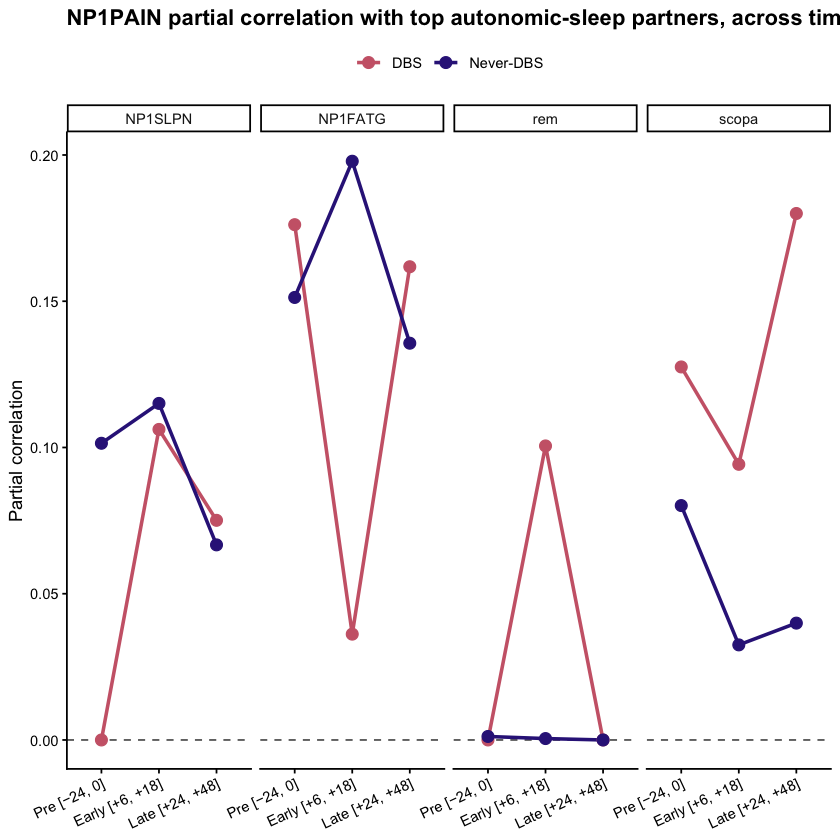

In [3]:
# Companion: line plot of |pcor| for the top-4 pain partners across windows × arms
top_partners <- c("scopa", "NP1SLPN", "rem", "NP1FATG")
pain_rows <- panels %>% dplyr::filter(row == "NP1PAIN", col %in% top_partners, arm != "All")
p_line <- ggplot(pain_rows, aes(window, pcor, colour = arm, group = arm)) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey40") +
  geom_line(linewidth = 1) + geom_point(size = 3) +
  facet_wrap(~ col, nrow = 1) +
  scale_colour_manual(values = c(`DBS` = "#CC6677", `Never-DBS` = "#332288"), name = NULL) +
  labs(title = "NP1PAIN partial correlation with top autonomic-sleep partners, across time",
       x = NULL, y = "Partial correlation") +
  theme_classic(base_size = 11) +
  theme(plot.title = element_text(face = "bold"),
        axis.text.x = element_text(angle = 25, hjust = 1), legend.position = "top")
p_line
save_fig(p_line, "FigureS2_pain_partner_lines", width = 11, height = 3.8)